<a href="https://colab.research.google.com/github/SilvanaBContreras/AA_TP1_G8/blob/main/AA_TP1_G8_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# boosting

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Levanto datos procesados en notebook EDA

In [ ]:
URL_BASE = 'https://github.com/SilvanaBContreras/AA_TP1_G8/raw/refs/heads/main/'

archivos_a_cargar = {
    'X_train_completo.parquet': 'X_train',
    'y_train.parquet': 'y_train',
    'X_test_completo.parquet': 'X_test',
    'y_test.parquet': 'y_test',
    'X_train_reducido.parquet': 'X_train_short',
    'X_test_reducido.parquet': 'X_test_short',
    'X_transf.parquet': 'X_transf',
    'y.parquet': 'y',
    'y_ternaria.parquet': 'y_ternaria',
    'y_ternaria.parquet': 'y_ternaria',
    'X_train_ternaria.parquet': 'X_train_ternaria',
    'X_test_ternaria.parquet': 'X_test_ternaria',
    'y_train_ternaria.parquet': 'y_train_ternaria',
    'y_test_ternaria.parquet': 'y_test_ternaria'
}

def cargar_conjunto(nombre_archivo):
    """Carga un archivo Parquet desde la URL de GitHub."""
    full_url = URL_BASE + nombre_archivo
    data = pd.read_parquet(full_url)

    # Si es un DataFrame con una sola columna (que era originalmente una Series 'y'),
    # la convertimos de vuelta a Series con .squeeze()
    if data.shape[1] == 1:
        return data.squeeze()

    return data

# Crear un diccionario para almacenar todas las variables cargadas
variables_cargadas = {}

# Cargar y asignar dinámicamente
for nombre_archivo, nombre_variable in archivos_a_cargar.items():
    datos = cargar_conjunto(nombre_archivo)
    variables_cargadas[nombre_variable] = datos
    print(f" Cargado {nombre_archivo} como la variable '{nombre_variable}'")

# Asignar las variables al espacio de nombres de la notebook
X_train = variables_cargadas['X_train']
y_train = variables_cargadas['y_train']
X_test = variables_cargadas['X_test']
y_test = variables_cargadas['y_test']
X_train_short = variables_cargadas['X_train_short']
X_test_short = variables_cargadas['X_test_short']
X_transf = variables_cargadas['X_transf']
y = variables_cargadas['y']
y_ternaria = variables_cargadas['y_ternaria']
X_train_ternaria = variables_cargadas['X_train_ternaria']
X_test_ternaria = variables_cargadas['X_test_ternaria']
y_train_ternaria = variables_cargadas['y_train_ternaria']
y_test_ternaria = variables_cargadas['y_test_ternaria']


print("\n--- Verificación Final ---")
print(f"Variable X_train cargada. Dimensiones: {X_train.shape}")
print(f"Variable X_train_short cargada. Dimensiones: {X_train_short.shape}")
print("¡Estás lista para comenzar a entrenar y comparar modelos! ")

 Cargado X_train_completo.parquet como la variable 'X_train'
 Cargado y_train.parquet como la variable 'y_train'
 Cargado X_test_completo.parquet como la variable 'X_test'
 Cargado y_test.parquet como la variable 'y_test'
 Cargado X_train_reducido.parquet como la variable 'X_train_short'
 Cargado X_test_reducido.parquet como la variable 'X_test_short'
 Cargado X_transf.parquet como la variable 'X_transf'
 Cargado y.parquet como la variable 'y'
 Cargado y_ternaria.parquet como la variable 'y_ternaria'
 Cargado X_train_ternaria.parquet como la variable 'X_train_ternaria'
 Cargado X_test_ternaria.parquet como la variable 'X_test_ternaria'
 Cargado y_train_ternaria.parquet como la variable 'y_train_ternaria'
 Cargado y_test_ternaria.parquet como la variable 'y_test_ternaria'

--- Verificación Final ---
Variable X_train cargada. Dimensiones: (40257, 51)
Variable X_train_short cargada. Dimensiones: (40257, 49)
¡Estás lista para comenzar a entrenar y comparar modelos! 


In [ ]:
print("\nDimensiones de:")
print(f"X_transf: {X_transf.shape}")
print(f"y: {y.shape}")

print(f"X_train: {X_train.shape}")
print(f"X_train_short: {X_train_short.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_test_short: {X_test_short.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"y_ternaria: {y_ternaria.shape}")
print(f"y_train_ternaria: {y_train_ternaria.shape}")
print(f"y_test_ternaria: {y_test_ternaria.shape}")


Dimensiones de:
X_transf: (57510, 51)
y: (57510,)
X_train: (40257, 51)
X_train_short: (40257, 49)
X_test: (17253, 51)
X_test_short: (17253, 49)
y_train: (40257,)
y_test: (17253,)
y_ternaria: (57510,)
y_train_ternaria: (40257,)
y_test_ternaria: (17253,)


In [ ]:
print(f"y_ternaria: {y_ternaria.shape}")

y_ternaria: (57510,)


In [ ]:
y_ternaria.value_counts()

,count
target_ternaria,
2,35685
1,14087
0,7738


# ADA BOOST


Se implementó AdaBoost mediante el algoritmo SAMME.R (Stagewise Additive Modeling using a Multi-class Exponential loss, variante con probabilidades continuas) propuesto por Zhu et al. (2006). Este algoritmo extiende AdaBoost
a clasificación multiclase utilizando estimaciones de probabilidad de clase en lugar de predicciones discretas, lo que resulta en una convergencia más rápida y robusta.

A diferencia del AdaBoost original que requiere error inferior al 50%, SAMME.R solo exige superar el nivel de azar (33.3% en clasificación ternaria). Se utilizaron árboles de decisión tipo "stump" con max_depth = 1 como weak learners, optimizando simultáneamente el número de estimadores (n_estimators), la tasa de aprendizaje (learning_rate) con búsqueda aleatorizada y validación cruzada estratificada de 5 folds.

Zhu, J., Rosset, S., Zou, H., & Hastie, T. (2006). Multi-class AdaBoost. Statistics and Its Interface, 2(3), 349-360.

## Optimizacion hiperparametros

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)

ada = AdaBoostClassifier(random_state=42)

param_dist = {
    "n_estimators": np.arange(50, 301, 5),
    "learning_rate": np.linspace(0.01, 1.0, 100)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    ada,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=0
)
search.fit(X_train_ternaria, y_train_ternaria)

best_ada = search.best_estimator_

print("AdaBoost (ternaria) - Mejores hiperparámetros")
print(search.best_params_)
print(f"CV F1_weighted (best): {search.best_score_:.4f}")

best_ada.fit(X_train_ternaria, y_train_ternaria)
y_pred  = best_ada.predict(X_test_ternaria)

acc  = accuracy_score(y_test_ternaria, y_pred)
prec_w = precision_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
rec_w  = recall_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
f1_w   = f1_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
prec_m = precision_score(y_test_ternaria, y_pred, average="macro", zero_division=0)
rec_m  = recall_score(y_test_ternaria, y_pred, average="macro", zero_division=0)
f1_m   = f1_score(y_test_ternaria, y_pred, average="macro", zero_division=0)

print("\n Métricas en TEST (resumen)")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision weighted: {prec_w:.4f} | macro: {prec_m:.4f}")
print(f"Recall    weighted: {rec_w:.4f} | macro: {rec_m:.4f}")
print(f"F1        weighted: {f1_w:.4f} | macro: {f1_m:.4f}")

print("\nClassification report (TEST) ")
print(classification_report(
    y_test_ternaria, y_pred,
    target_names=['Graduado', 'En Curso', 'Desertor'],
    digits=3, zero_division=0
))

AdaBoost (ternaria) - Mejores hiperparámetros
{'n_estimators': np.int64(295), 'learning_rate': np.float64(0.9500000000000001)}
CV F1_weighted (best): 0.7746

 Métricas en TEST (resumen)
Accuracy          : 0.7826
Precision weighted: 0.7727 | macro: 0.7234
Recall    weighted: 0.7826 | macro: 0.6540
F1        weighted: 0.7722 | macro: 0.6776

Classification report (TEST) 
              precision    recall  f1-score   support

    Graduado      0.701     0.435     0.537      2321
    En Curso      0.621     0.595     0.608      4226
    Desertor      0.848     0.932     0.888     10706

    accuracy                          0.783     17253
   macro avg      0.723     0.654     0.678     17253
weighted avg      0.773     0.783     0.772     17253



In [ ]:
import sklearn
print(f"Versión sklearn: {sklearn.__version__}")
print(f"Algoritmo reportado: {best_ada.algorithm}")

# Ver si tiene el atributo interno que realmente usa
if hasattr(best_ada, '_algorithm'):
    print(f"Algoritmo real (_algorithm): {best_ada._algorithm}")

# Verificar si puede dar probabilidades (signo de SAMME.R)
try:
    proba = best_ada.predict_proba(X_test_ternaria[:5])
    print("✓ El modelo puede calcular probabilidades → probablemente SAMME.R")
except:
    print("✗ No calcula probabilidades → probablemente SAMME")

Versión sklearn: 1.6.1
Algoritmo reportado: deprecated
✓ El modelo puede calcular probabilidades → probablemente SAMME.R


## Matriz de confusión

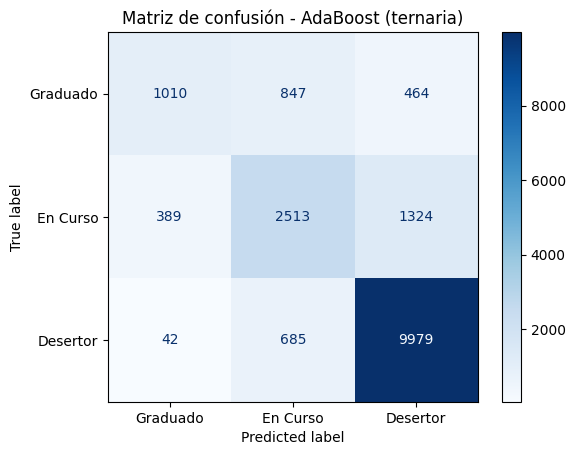

In [ ]:
cm = confusion_matrix(y_test_ternaria, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Graduado','En Curso','Desertor'])
disp.plot(values_format="d", cmap="Blues")
plt.title("Matriz de confusión - AdaBoost (ternaria)")
plt.show()


## AUC roc

In [ ]:


try:
    clases_presentes = np.unique(y_test_ternaria)
    if len(clases_presentes) < 3:
        print(f"ROC-AUC OVO (macro): omitido (faltan clases en test: {clases_presentes.tolist()})")
    else:
        y_proba = best_ada.predict_proba(X_test_ternaria)
        auc_macro_ovo = roc_auc_score(y_test_ternaria, y_proba, multi_class="ovo", average="macro")
        print(f"ROC-AUC OVO (macro): {auc_macro_ovo:.4f}")
except Exception as e:
    print("No fue posible calcular ROC-AUC OVO:", e)


ROC-AUC OVO (macro): 0.8227


## Curva de complejidad

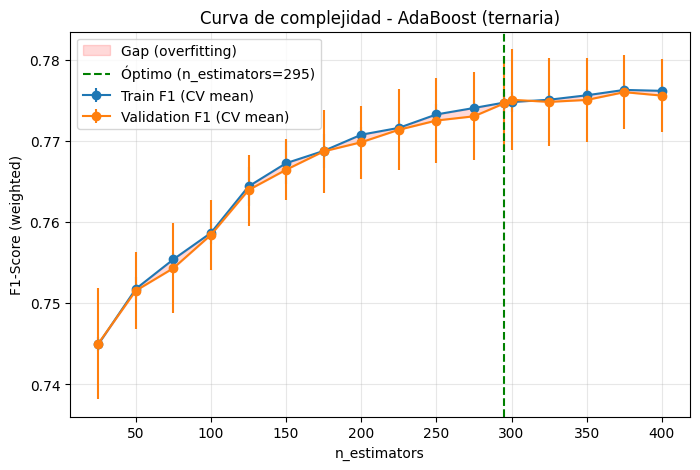

ANÁLISIS DE OVERFITTING - AdaBoost (ternaria)
n_estimators óptimo (RandomSearch): 295
Train F1 en óptimo: 0.7747 ± 0.0013
Val   F1 en óptimo: 0.7746 ± 0.0059
Gap en óptimo     : 0.0001


In [ ]:
# Curva de complejidad: variamos n_estimators con el learning_rate óptimo
best_lr = search.best_params_["learning_rate"]
opt_n   = search.best_params_["n_estimators"]

# Aseguramos que el óptimo esté en la grilla
base_grid = np.arange(25, 401, 25)
n_grid = np.unique(np.r_[base_grid, opt_n])

train_means, valid_means, train_stds, valid_stds = [], [], [], []

for n in n_grid:
    mdl = AdaBoostClassifier(n_estimators=n, learning_rate=best_lr, random_state=42)
    res = cross_validate(
        mdl, X_train_ternaria, y_train_ternaria,
        cv=cv, scoring="f1_weighted",
        n_jobs=-1, return_train_score=True
    )
    train_means.append(res["train_score"].mean()); train_stds.append(res["train_score"].std())
    valid_means.append(res["test_score"].mean());  valid_stds.append(res["test_score"].std())

train_means = np.array(train_means)
valid_means = np.array(valid_means)
train_stds  = np.array(train_stds)
valid_stds  = np.array(valid_stds)
gap = train_means - valid_means

# índice exacto del óptimo en la grilla
best_idx = np.where(n_grid == opt_n)[0][0]

# Plot con 2 líneas + barras de error + gap + línea vertical en el óptimo
plt.figure(figsize=(8,5))
plt.errorbar(n_grid, train_means, yerr=train_stds, fmt='-o', label="Train F1 (CV mean)")
plt.errorbar(n_grid, valid_means, yerr=valid_stds, fmt='-o', label="Validation F1 (CV mean)")
plt.fill_between(n_grid, train_means, valid_means, alpha=0.15, color='red', label='Gap (overfitting)')
plt.axvline(x=opt_n, color='green', linestyle='--',
            label=f"Óptimo (n_estimators={opt_n})")
plt.xlabel("n_estimators")
plt.ylabel("F1-Score (weighted)")
plt.title("Curva de complejidad - AdaBoost (ternaria)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("ANÁLISIS DE OVERFITTING - AdaBoost (ternaria)")
print(f"n_estimators óptimo (RandomSearch): {opt_n}")
print(f"Train F1 en óptimo: {train_means[best_idx]:.4f} ± {train_stds[best_idx]:.4f}")
print(f"Val   F1 en óptimo: {valid_means[best_idx]:.4f} ± {valid_stds[best_idx]:.4f}")
print(f"Gap en óptimo     : {gap[best_idx]:.4f}")
print("="*60)


## Importancia de variables

,Importance
ratio_aprobadas_inscrito_2sem_fe,0.257451
Pago_de_matrícula_al_día_transformed,0.186883
ratio_aprobadas_inscrito_1sem_fe,0.088856
Unidades_curriculares_2do_semestre_(aprobadas),0.080369
Tiene_deuda_transformed,0.064031
Carrera_Ingeniería Informática,0.055047
Unidades_curriculares_1er_semestre_(aprobadas),0.041485
Carrera_Psicología,0.037370
Nota_promedio_en_el_2do_semestre,0.034932
Cantidad_de_evaluaciones_en_el_2do_semestre_,0.022442


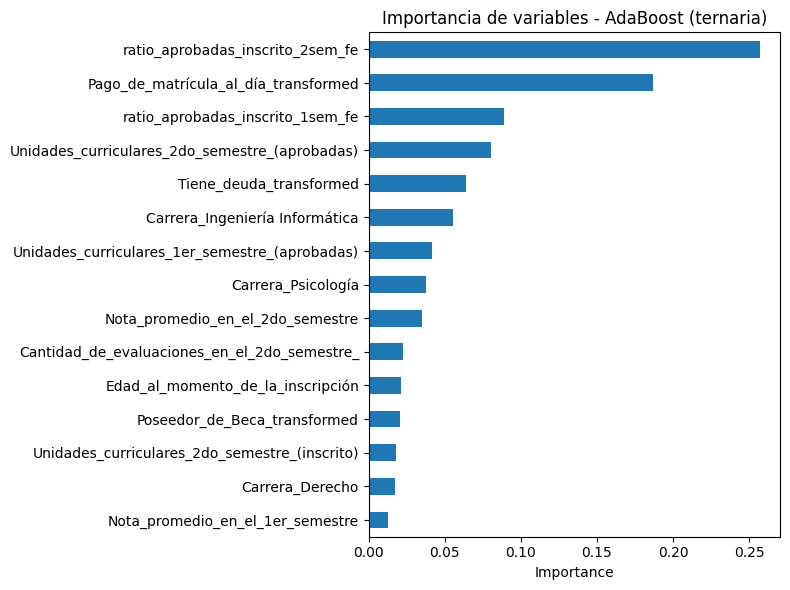

,Feature,Importance,%,cumsum_%
0,ratio_aprobadas_inscrito_2sem_fe,0.257451,25.745131,25.745131
1,Pago_de_matrícula_al_día_transformed,0.186883,18.688306,44.433437
2,ratio_aprobadas_inscrito_1sem_fe,0.088856,8.885622,53.319059
3,Unidades_curriculares_2do_semestre_(aprobadas),0.080369,8.036878,61.355937
4,Tiene_deuda_transformed,0.064031,6.403113,67.759050
5,Carrera_Ingeniería Informática,0.055047,5.504676,73.263725
6,Unidades_curriculares_1er_semestre_(aprobadas),0.041485,4.148516,77.412242
7,Carrera_Psicología,0.037370,3.737036,81.149277
8,Nota_promedio_en_el_2do_semestre,0.034932,3.493193,84.642471
9,Cantidad_de_evaluaciones_en_el_2do_semestre_,0.022442,2.244223,86.886693


In [ ]:
feat_names = getattr(X_train_ternaria, "columns", range(X_train_ternaria.shape[1]))
imp = pd.Series(best_ada.feature_importances_, index=feat_names).sort_values(ascending=False)

topk = min(15, len(imp))
display(imp.head(topk).to_frame("Importance"))  # opcional: tabla
plt.figure(figsize=(8,6))
imp.head(topk).iloc[::-1].plot(kind="barh")
plt.title("Importancia de variables - AdaBoost (ternaria)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

imp_df = imp.reset_index()
imp_df.columns = ["Feature","Importance"]
imp_df["%"] = 100 * imp_df["Importance"] / imp_df["Importance"].sum()
imp_df["cumsum_%"] = imp_df["%"].cumsum()
display(imp_df.head(topk))


#CAMBIO VERSION SCIKIT

In [ ]:
# Celda 1: Instalar versión antigua que tiene SAMME.R
!pip install scikit-learn==1.3.2

# Ahora REINICIAR RUNTIME (Runtime > Restart runtime)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cuml-cu12 25.6.0 requires scikit-learn>=1.5, but you have scikit-learn 1.3.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0

In [ ]:
# Celda 2: Verificar versión y probar SAMME.R
import sklearn
print(f"Versión: {sklearn.__version__}")

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd



Versión: 1.3.2


# prueba SAMME.R

In [ ]:
URL_BASE = 'https://github.com/SilvanaBContreras/AA_TP1_G8/raw/refs/heads/main/'

archivos_a_cargar = {
    'X_train_completo.parquet': 'X_train',
    'y_train.parquet': 'y_train',
    'X_test_completo.parquet': 'X_test',
    'y_test.parquet': 'y_test',
    'X_train_reducido.parquet': 'X_train_short',
    'X_test_reducido.parquet': 'X_test_short',
    'X_transf.parquet': 'X_transf',
    'y.parquet': 'y',
    'y_ternaria.parquet': 'y_ternaria',
    'y_ternaria.parquet': 'y_ternaria',
    'X_train_ternaria.parquet': 'X_train_ternaria',
    'X_test_ternaria.parquet': 'X_test_ternaria',
    'y_train_ternaria.parquet': 'y_train_ternaria',
    'y_test_ternaria.parquet': 'y_test_ternaria'
}

def cargar_conjunto(nombre_archivo):
    """Carga un archivo Parquet desde la URL de GitHub."""
    full_url = URL_BASE + nombre_archivo
    data = pd.read_parquet(full_url)

    # Si es un DataFrame con una sola columna (que era originalmente una Series 'y'),
    # la convertimos de vuelta a Series con .squeeze()
    if data.shape[1] == 1:
        return data.squeeze()

    return data

# Crear un diccionario para almacenar todas las variables cargadas
variables_cargadas = {}

# Cargar y asignar dinámicamente
for nombre_archivo, nombre_variable in archivos_a_cargar.items():
    datos = cargar_conjunto(nombre_archivo)
    variables_cargadas[nombre_variable] = datos
    print(f" Cargado {nombre_archivo} como la variable '{nombre_variable}'")

# Asignar las variables al espacio de nombres de la notebook
X_train = variables_cargadas['X_train']
y_train = variables_cargadas['y_train']
X_test = variables_cargadas['X_test']
y_test = variables_cargadas['y_test']
X_train_short = variables_cargadas['X_train_short']
X_test_short = variables_cargadas['X_test_short']
X_transf = variables_cargadas['X_transf']
y = variables_cargadas['y']
y_ternaria = variables_cargadas['y_ternaria']
X_train_ternaria = variables_cargadas['X_train_ternaria']
X_test_ternaria = variables_cargadas['X_test_ternaria']
y_train_ternaria = variables_cargadas['y_train_ternaria']
y_test_ternaria = variables_cargadas['y_test_ternaria']


 Cargado X_train_completo.parquet como la variable 'X_train'
 Cargado y_train.parquet como la variable 'y_train'
 Cargado X_test_completo.parquet como la variable 'X_test'
 Cargado y_test.parquet como la variable 'y_test'
 Cargado X_train_reducido.parquet como la variable 'X_train_short'
 Cargado X_test_reducido.parquet como la variable 'X_test_short'
 Cargado X_transf.parquet como la variable 'X_transf'
 Cargado y.parquet como la variable 'y'
 Cargado y_ternaria.parquet como la variable 'y_ternaria'
 Cargado X_train_ternaria.parquet como la variable 'X_train_ternaria'
 Cargado X_test_ternaria.parquet como la variable 'X_test_ternaria'
 Cargado y_train_ternaria.parquet como la variable 'y_train_ternaria'
 Cargado y_test_ternaria.parquet como la variable 'y_test_ternaria'


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
import numpy as np

# AdaBoost con SAMME.R (requiere sklearn < 1.6)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    algorithm='SAMME.R',
    random_state=42
)

param_dist = {
    "n_estimators": np.arange(50, 400, 5),
    "learning_rate": np.linspace(0.01, 1.0, 100),
    "estimator__max_depth": [1, 2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    ada,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train_ternaria, y_train_ternaria.values.ravel())

best_ada = search.best_estimator_

print("AdaBoost SAMME.R (ternaria) - Mejores hiperparámetros")
print(search.best_params_)
print(f"CV F1_weighted (best): {search.best_score_:.4f}")

y_pred = best_ada.predict(X_test_ternaria)

acc = accuracy_score(y_test_ternaria, y_pred)
prec_w = precision_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
rec_w = recall_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
f1_w = f1_score(y_test_ternaria, y_pred, average="weighted", zero_division=0)
prec_m = precision_score(y_test_ternaria, y_pred, average="macro", zero_division=0)
rec_m = recall_score(y_test_ternaria, y_pred, average="macro", zero_division=0)
f1_m = f1_score(y_test_ternaria, y_pred, average="macro", zero_division=0)

print("\nMétricas en TEST (resumen)")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision weighted: {prec_w:.4f} | macro: {prec_m:.4f}")
print(f"Recall    weighted: {rec_w:.4f} | macro: {rec_m:.4f}")
print(f"F1        weighted: {f1_w:.4f} | macro: {f1_m:.4f}")

print("\nClassification report (TEST)")
print(classification_report(
    y_test_ternaria, y_pred,
    target_names=['Graduado', 'En Curso', 'Desertor'],
    digits=3, zero_division=0
))

# Verificar que realmente está usando SAMME.R
print(f"\nAlgoritmo confirmado: {best_ada.algorithm}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
AdaBoost SAMME.R (ternaria) - Mejores hiperparámetros
{'n_estimators': 330, 'learning_rate': 0.24000000000000002, 'estimator__max_depth': 2}
CV F1_weighted (best): 0.7833

Métricas en TEST (resumen)
Accuracy          : 0.7885
Precision weighted: 0.7797 | macro: 0.7296
Recall    weighted: 0.7885 | macro: 0.6670
F1        weighted: 0.7797 | macro: 0.6892

Classification report (TEST)
              precision    recall  f1-score   support

    Graduado      0.702     0.459     0.555      2321
    En Curso      0.632     0.613     0.622      4226
    Desertor      0.855     0.929     0.891     10706

    accuracy                          0.789     17253
   macro avg      0.730     0.667     0.689     17253
weighted avg      0.780     0.789     0.780     17253


Algoritmo confirmado: SAMME.R


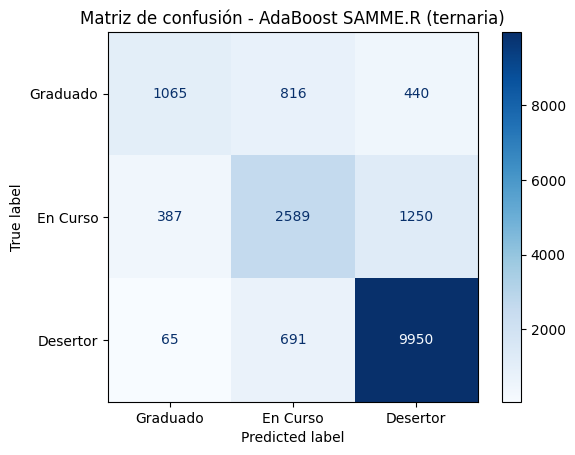

ROC-AUC OVO (macro) SAMME.R: 0.8113


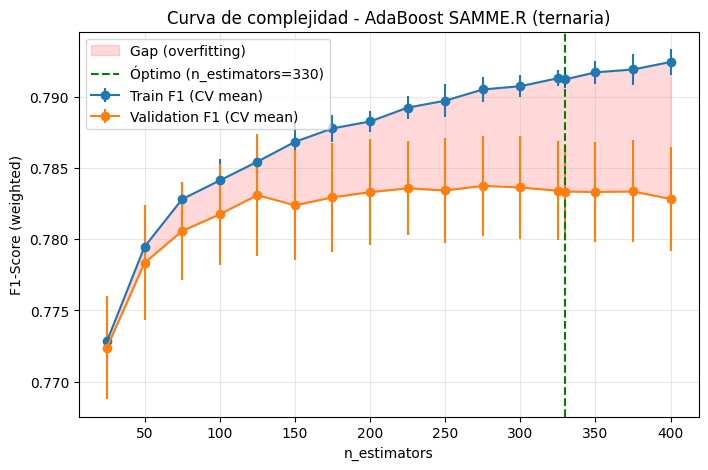

ANÁLISIS DE OVERFITTING - AdaBoost SAMME.R (ternaria)
n_estimators óptimo (RandomSearch): 330
learning_rate óptimo: 0.2400
max_depth óptimo: 2
Train F1 en óptimo: 0.7912 ± 0.0006
Val   F1 en óptimo: 0.7833 ± 0.0033
Gap en óptimo     : 0.0079


,Importance (SAMME.R)
ratio_aprobadas_inscrito_2sem_fe,0.086793
Cualificación_promedio_de_estudios_previos,0.076469
Nota_promedio_en_el_1er_semestre,0.075232
Puntaje_en_examen_de_ingreso,0.072672
Nota_promedio_en_el_2do_semestre,0.069411
Cantidad_de_evaluaciones_en_el_2do_semestre_,0.062244
Edad_al_momento_de_la_inscripción,0.060147
ratio_aprobadas_inscrito_1sem_fe,0.056895
Cantidad_de_evaluaciones_en_el_1er_semestre,0.044543
lag_nota_promedio_fe,0.044497


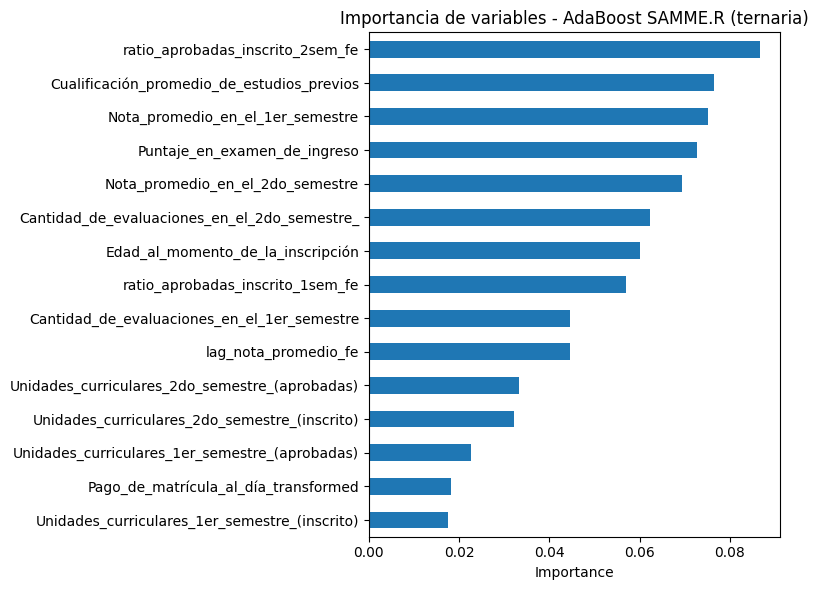

,Feature,Importance,%,cumsum_%
0,ratio_aprobadas_inscrito_2sem_fe,0.086793,8.679252,8.679252
1,Cualificación_promedio_de_estudios_previos,0.076469,7.646880,16.326133
2,Nota_promedio_en_el_1er_semestre,0.075232,7.523167,23.849300
3,Puntaje_en_examen_de_ingreso,0.072672,7.267239,31.116539
4,Nota_promedio_en_el_2do_semestre,0.069411,6.941121,38.057659
5,Cantidad_de_evaluaciones_en_el_2do_semestre_,0.062244,6.224422,44.282081
6,Edad_al_momento_de_la_inscripción,0.060147,6.014749,50.296830
7,ratio_aprobadas_inscrito_1sem_fe,0.056895,5.689543,55.986373
8,Cantidad_de_evaluaciones_en_el_1er_semestre,0.044543,4.454296,60.440668
9,lag_nota_promedio_fe,0.044497,4.449681,64.890350


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate

## Matriz de confusión SAMME.R
cm_sammer = confusion_matrix(y_test_ternaria, y_pred)
disp_sammer = ConfusionMatrixDisplay(
    confusion_matrix=cm_sammer,
    display_labels=['Graduado','En Curso','Desertor']
)
disp_sammer.plot(values_format="d", cmap="Blues")
plt.title("Matriz de confusión - AdaBoost SAMME.R (ternaria)")
plt.show()

## AUC ROC SAMME.R
try:
    clases_presentes_sammer = np.unique(y_test_ternaria)
    if len(clases_presentes_sammer) < 3:
        print(f"ROC-AUC OVO (macro): omitido (faltan clases en test: {clases_presentes_sammer.tolist()})")
    else:
        y_proba_sammer = best_ada.predict_proba(X_test_ternaria)
        auc_macro_ovo_sammer = roc_auc_score(y_test_ternaria, y_proba_sammer, multi_class="ovo", average="macro")
        print(f"ROC-AUC OVO (macro) SAMME.R: {auc_macro_ovo_sammer:.4f}")
except Exception as e:
    print("No fue posible calcular ROC-AUC OVO:", e)

## Curva de complejidad SAMME.R
best_lr_sammer = search.best_params_["learning_rate"]
opt_n_sammer = search.best_params_["n_estimators"]
best_depth_sammer = search.best_params_.get("estimator__max_depth", 1)

base_grid_sammer = np.arange(25, 401, 25)
n_grid_sammer = np.unique(np.r_[base_grid_sammer, opt_n_sammer])

train_means_sammer = []
valid_means_sammer = []
train_stds_sammer = []
valid_stds_sammer = []

for n in n_grid_sammer:
    mdl_sammer = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=best_depth_sammer, random_state=42),
        n_estimators=n,
        learning_rate=best_lr_sammer,
        algorithm='SAMME.R',
        random_state=42
    )
    res_sammer = cross_validate(
        mdl_sammer, X_train_ternaria, y_train_ternaria.values.ravel(),
        cv=cv, scoring="f1_weighted",
        n_jobs=-1, return_train_score=True
    )
    train_means_sammer.append(res_sammer["train_score"].mean())
    train_stds_sammer.append(res_sammer["train_score"].std())
    valid_means_sammer.append(res_sammer["test_score"].mean())
    valid_stds_sammer.append(res_sammer["test_score"].std())

train_means_sammer = np.array(train_means_sammer)
valid_means_sammer = np.array(valid_means_sammer)
train_stds_sammer = np.array(train_stds_sammer)
valid_stds_sammer = np.array(valid_stds_sammer)
gap_sammer = train_means_sammer - valid_means_sammer

best_idx_sammer = np.where(n_grid_sammer == opt_n_sammer)[0][0]

plt.figure(figsize=(8,5))
plt.errorbar(n_grid_sammer, train_means_sammer, yerr=train_stds_sammer,
             fmt='-o', label="Train F1 (CV mean)")
plt.errorbar(n_grid_sammer, valid_means_sammer, yerr=valid_stds_sammer,
             fmt='-o', label="Validation F1 (CV mean)")
plt.fill_between(n_grid_sammer, train_means_sammer, valid_means_sammer,
                 alpha=0.15, color='red', label='Gap (overfitting)')
plt.axvline(x=opt_n_sammer, color='green', linestyle='--',
            label=f"Óptimo (n_estimators={opt_n_sammer})")
plt.xlabel("n_estimators")
plt.ylabel("F1-Score (weighted)")
plt.title("Curva de complejidad - AdaBoost SAMME.R (ternaria)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ANÁLISIS DE OVERFITTING - AdaBoost SAMME.R (ternaria)")
print(f"n_estimators óptimo (RandomSearch): {opt_n_sammer}")
print(f"learning_rate óptimo: {best_lr_sammer:.4f}")
print(f"max_depth óptimo: {best_depth_sammer}")
print(f"Train F1 en óptimo: {train_means_sammer[best_idx_sammer]:.4f} ± {train_stds_sammer[best_idx_sammer]:.4f}")
print(f"Val   F1 en óptimo: {valid_means_sammer[best_idx_sammer]:.4f} ± {valid_stds_sammer[best_idx_sammer]:.4f}")
print(f"Gap en óptimo     : {gap_sammer[best_idx_sammer]:.4f}")
print("="*60)

## Importancia de variables SAMME.R
feat_names_sammer = getattr(X_train_ternaria, "columns", range(X_train_ternaria.shape[1]))
imp_sammer = pd.Series(best_ada.feature_importances_, index=feat_names_sammer).sort_values(ascending=False)
topk_sammer = min(15, len(imp_sammer))

display(imp_sammer.head(topk_sammer).to_frame("Importance (SAMME.R)"))

plt.figure(figsize=(8,6))
imp_sammer.head(topk_sammer).iloc[::-1].plot(kind="barh")
plt.title("Importancia de variables - AdaBoost SAMME.R (ternaria)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

imp_df_sammer = imp_sammer.reset_index()
imp_df_sammer.columns = ["Feature","Importance"]
imp_df_sammer["%"] = 100 * imp_df_sammer["Importance"] / imp_df_sammer["Importance"].sum()
imp_df_sammer["cumsum_%"] = imp_df_sammer["%"].cumsum()
display(imp_df_sammer.head(topk_sammer))

# RESTAURO SCI KIT

In [ ]:
# Volver a la versión actual
!pip install --upgrade scikit-learn

# Reiniciar runtime nuevamente
# Runtime > Restart runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 40.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
